In [191]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [192]:
import os
os.chdir("/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/")

In [193]:
%%capture
!pip install optuna torch plotly

In [194]:
# Import Packages
import os
import pandas as pd
import numpy as np
import datetime
import time
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import optuna
import matplotlib.pyplot as plt
import pickle as pkl
pd.set_option('display.max_columns', None)

In [195]:
from src.preprocessing.data_preparation import DataPreparation
from src.preprocessing.feature_scaling import robust_scaling, min_max_scaling
from src.model.base_model.quantile_tcn_model import QuantileTCNModel
from src.utils.helper_functions import get_approach
from src.utils.evaluate import evaluate_model
from src.utils.train import quantile_tcn_train
from src.utils.test import quantile_test
from src.utils.postprocessing import process_quantile_data
from src.utils.metrics import quantile_performance_matrix

In [196]:
warnings.filterwarnings("ignore")
SEED = 1
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

best_val_loss = float('inf')

In [197]:
def pinball_loss(outputs, targets, quantiles, reduction="mean"):
    assert len(quantiles) == outputs.shape[-1], "Number of quantiles should match number of outputs"
    assert outputs.shape[:-1] == targets.shape, "Output and target shape mismatch"
    loss = 0
    for i, q in enumerate(quantiles):
        err = targets - outputs[:, :, i]
        loss += torch.mean(torch.max((q-1) * err, q * err))
    if reduction == "mean":
        loss = loss / len(quantiles)
    elif reduction == "sum":
        pass
    elif reduction == "none":
        return loss

    return loss

In [198]:
def objective(trial, epochs):
    global best_val_loss

    num_channels = trial.suggest_categorical('num_channels',
                                             [[2 ** i] * (j + 1) for i in range(4, 7) for j in range(0, 2)])
    kernel_size = trial.suggest_int('kernel_size', 2, 5)
    dropout = trial.suggest_float('dropout', 0.2, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    epochs = epochs

    train_loader = torch.utils.data.DataLoader(base_train_data, batch_size=batch_size, shuffle=False)
    val_loader = torch.utils.data.DataLoader(base_val_data, batch_size=batch_size, shuffle=False)

    # create the model
    model = QuantileTCNModel(input_size=base_x_train.shape[2], output_size=base_y_train.shape[1], num_channels=num_channels,
                kernel_size=kernel_size, dropout=dropout, quantiles=QUANTILES).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate,  weight_decay=1e-4)

    results = []
    train_loss = []
    val_loss = []
    quantiles = QUANTILES
    reduction = REDUCTION

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = []
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs.permute(0, 2, 1))
            loss = pinball_loss(outputs, targets, quantiles, reduction)
            loss.backward()
            optimizer.step()
            epoch_train_loss.append(loss.item())
        avg_train_loss = sum(epoch_train_loss) / len(epoch_train_loss)
        train_loss.append(avg_train_loss)

        model.eval()
        epoch_val_loss = []
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                outputs = model(inputs.permute(0, 2, 1))
                loss = pinball_loss(outputs, targets, quantiles, reduction)
                epoch_val_loss.append(loss.item())
        avg_val_loss = sum(epoch_val_loss) / len(epoch_val_loss)
        val_loss.append(avg_val_loss)

        trial.report(avg_val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        trial.set_user_attr("num_channels", num_channels)
        trial.set_user_attr("kernel_size", kernel_size)
        trial.set_user_attr("dropout", dropout)
        trial.set_user_attr("learning_rate", learning_rate)
        trial.set_user_attr("batch_size", batch_size)
        trial.set_user_attr(f"train_loss_epoch_{epoch}", avg_train_loss)
        trial.set_user_attr(f"val_loss_epoch_{epoch}", avg_val_loss)

        if avg_val_loss < best_val_loss:
            # Save the best model
            best_val_loss = avg_val_loss
            if not os.path.exists(os.path.dirname(base_model_path)):
                os.makedirs(os.path.dirname(base_model_path))
            torch.save(model.state_dict(), base_model_path)

    return avg_val_loss

In [217]:
def extract_trial_results(study):
    trials = study.trials
    results = []

    for trial in trials:
        hyperparameters = {
            "num_channels": trial.user_attrs.get("num_channels"),
            "kernel_size": trial.user_attrs.get("kernel_size"),
            "dropout": trial.user_attrs.get("dropout"),
            "learning_rate": trial.user_attrs.get("learning_rate"),
            "batch_size": trial.user_attrs.get("batch_size")
        }

        epoch_losses = []
        num_epochs = 0
        while True:
            epoch_train_loss = trial.user_attrs.get(f"train_loss_epoch_{num_epochs}", None)
            epoch_val_loss = trial.user_attrs.get(f"val_loss_epoch_{num_epochs}", None)

            if epoch_train_loss is not None and epoch_val_loss is not None:
                epoch_loss = {
                    "epoch": num_epochs,
                    "train_loss": epoch_train_loss,
                    "val_loss": epoch_val_loss
                }
                epoch_losses.append(epoch_loss)
                num_epochs += 1
            else:
                break

        result = {
            "trial_number": trial.number,
            "val_loss": trial.value,
            "hyperparameters": hyperparameters,
            "epoch_losses": epoch_losses
        }

        results.append(result)

    return results

In [199]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}\n")

Device: cpu



In [200]:
if os.path.exists('/mnt/work/dkale/dkale_Colab/experiments_0.2/'):

    root_dir = '/mnt/work/dkale/dkale_Colab/experiments_0.2/'
else:
    root_dir = '/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/'

current_date = datetime.datetime.now().strftime("%d%m%Y")
approach = get_approach(model_type=0)

In [201]:
used_model = "TCN"
model_version = "1.0"
loss_function_name = "Quantile_loss"
optimization_technique = "Optuna"

In [202]:
# Define subdirectories
root_data_dir = root_dir + 'data/'
preprocessed_dir = root_data_dir + 'preprocessed/ACN/'
train_val_test_dir = root_data_dir + 'train_val_test/ACN/'
base_train_val_test_dir = train_val_test_dir + 'base_model'
result_dir = root_dir + 'result/'

# Base Directories
base_train_val_test_dir = train_val_test_dir + 'base_model/'
base_result_dir = result_dir + 'base_result/'
base_model_dir = base_result_dir + 'model/'
base_loss_metrics_dir = base_result_dir + 'loss_metrics'
base_permormance_metrics_dir = base_result_dir + 'performance_metrics'
base_trial_metrics_dir = base_result_dir + 'trial_metrics'
base_test_result_dir = base_result_dir + 'test_result'

In [203]:
# Define parameters
HOURS = 24
PAST_DAYS = 7
FUTURE_DAYS = 1
N_PAST = HOURS * PAST_DAYS
N_FUTURE = HOURS * FUTURE_DAYS
EPOCHS = 200
PATIENCE = 10

QUANTILES = [0.1, 0.5, 0.9]
REDUCTION = 'sum'
N_TRIALS = 50

In [204]:
study_name = f"Base Model, Used Model: {used_model}, Model Version: {model_version}, Loss Function: {loss_function_name}, Optimization Technique: {optimization_technique}, PAST DAYS: {PAST_DAYS} ---> FUTURE DAYS: {FUTURE_DAYS}"
common_file_name = f"{approach}_{used_model}_{model_version}_{loss_function_name}_{optimization_technique}_{PAST_DAYS}.0_{FUTURE_DAYS}.0_{current_date}"

In [205]:
base_df = pd.read_csv(f'{preprocessed_dir}finalVer03_caltech_acn_MultiSource.csv')

In [206]:
base_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16550 entries, 0 to 16549
Columns: 144 entries, doneChargingTime to lag_2
dtypes: float64(117), int64(26), object(1)
memory usage: 18.2+ MB


In [207]:
base_df.drop(columns = ['siteID'], axis = 1, inplace = True)

In [208]:
minmax_cols = ['energyPriceTotal', 'EVSEcount', 'EVSE_AV', 'EVSE_CC32', 'EVSE_CC64', 'EVSE_DX', 'EVSE_TWC', 'claimedCount', 'unclaimedCount', 'NotAvailable', 'freeStationCount',
               'paidStationCount', '2 metre temperature', 'Total Precipitation', 'Water equivalent of accumulated snow depth (deprecated)', '2 metre relative humidity',
               '2 metre specific humidity', 'Surface pressure', 'Visibility', 'Total Cloud Cover', 'lag_1', 'lag_2', 'Smoothed_kWhDeliveredTotal'] + ['dayCategoryEF{}'.format(i)
               for i in range(1, 6)] + ['stationIDEF{}'.format(i) for i in range(1, 101)]

sin_cosine_cols = ['Hour_of_Day', 'Day_Of_Week', 'Day_Of_year', 'Month_Of_Year', 'Season']

base_df_scaled, base_df_scaling_params = min_max_scaling(df = base_df, minmax_cols=minmax_cols, sin_cos_cols=sin_cosine_cols, column_name='Smoothed_kWhDeliveredTotal')

In [209]:
base_timestamp_list = base_df_scaled["doneChargingTime"].tolist()

In [210]:
total_data_points = len(base_df_scaled)

train_size = int(0.7 * total_data_points)
val_size = int(0.2 * total_data_points)
test_size = total_data_points - train_size - val_size

base_train_df = base_df_scaled.iloc[:train_size]
base_val_df = base_df_scaled.iloc[train_size:train_size + val_size]
base_test_df = base_df_scaled.iloc[train_size + val_size:]


In [211]:
# base_train_df.shape, base_val_df.shape, base_test_df.shape

((11585, 148), (3310, 148), (1655, 148))

In [160]:
# base_train_df.to_csv(
#     rf'{base_train_val_test_dir}acn_caltech_jpl_train_0.2_0.1_22_06_2023.csv',
#     index=False)
# base_val_df.to_csv(
#     rf'{base_train_val_test_dir}acn_caltech_jpl_val_0.2_0.1_22_06_2023.csv',
#     index=False)
# base_test_df.to_csv(
#     rf'{base_train_val_test_dir}acn_caltech_jpl_test_0.2_0.1_22_06_2023.csv',
#     index=False)

# BASE_TRAIN_FILE_NAME = rf'{base_train_val_test_dir}acn_caltech_jpl_train_0.2_0.1_22_06_2023.csv'
# BASE_VAL_FILE_NAME = rf'{base_train_val_test_dir}acn_caltech_jpl_val_0.2_0.1_22_06_2023.csv'
# BASETEST_FILE_NAME = rf'{base_train_val_test_dir}acn_caltech_jpl_test_0.2_0.1_22_06_2023.csv'

In [212]:
dp = DataPreparation(n_future= N_FUTURE, n_past= N_PAST)

In [213]:
base_x_train, base_y_train = dp.prepare_data(dataframe = base_train_df)
base_x_val, base_y_val = dp.prepare_data(dataframe = base_val_df)
base_x_test, base_y_test = dp.prepare_data(dataframe = base_test_df)

In [215]:
base_x_train.shape, base_y_train.shape, base_x_val.shape, base_y_val.shape, base_x_test.shape, base_y_test.shape

((11394, 168, 147),
 (11394, 24),
 (3119, 168, 147),
 (3119, 24),
 (1464, 168, 147),
 (1464, 24))

In [164]:
base_x_train = base_x_train[:128]
base_y_train = base_y_train[:128]
base_x_val = base_x_val[:128]
base_y_val = base_y_val[:128]
base_x_test = base_x_test[:128]
base_y_test = base_y_test[:128]

In [165]:
base_train_data = TensorDataset(torch.from_numpy(base_x_train).float(), torch.from_numpy(base_y_train).float())
base_val_data = TensorDataset(torch.from_numpy(base_x_val).float(), torch.from_numpy(base_y_val).float())
base_test_data = TensorDataset(torch.from_numpy(base_x_test).float(), torch.from_numpy(base_y_test).float())

In [166]:
N_TRIALS = 5
EPOCHS = 2

In [167]:
base_model_name = f'{common_file_name}.pt'
base_model_path = os.path.join(base_model_dir, base_model_name)
print("Hyperparameter Searching started..................\n")
study = optuna.create_study(study_name=study_name, direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(lambda trial: objective(trial, epochs=EPOCHS), n_trials=N_TRIALS)
print(f'\nThe base trained model: {base_model_name} has been successfully saved: "{base_model_path}".\n')

[I 2023-10-11 07:47:21,338] A new study created in memory with name: Base Model, Used Model: TCN, Model Version: 1.0, Loss Function: Quantile_loss, Optimization Technique: Optuna, PAST DAYS: 7 ---> FUTURE DAYS: 1


Hyperparameter Searching started..................



[I 2023-10-11 07:47:21,887] Trial 0 finished with value: 0.29417145252227783 and parameters: {'num_channels': [16, 16], 'kernel_size': 2, 'dropout': 0.30366821811291433, 'learning_rate': 0.00038642916535526494, 'batch_size': 256}. Best is trial 0 with value: 0.29417145252227783.
[I 2023-10-11 07:47:22,445] Trial 1 finished with value: 0.1853378713130951 and parameters: {'num_channels': [16, 16], 'kernel_size': 2, 'dropout': 0.25943044672546367, 'learning_rate': 0.015957993164212966, 'batch_size': 64}. Best is trial 1 with value: 0.1853378713130951.
[I 2023-10-11 07:47:22,914] Trial 2 finished with value: 0.19363391399383545 and parameters: {'num_channels': [16, 16], 'kernel_size': 2, 'dropout': 0.32633228750151566, 'learning_rate': 0.06785129181994787, 'batch_size': 128}. Best is trial 1 with value: 0.1853378713130951.
[I 2023-10-11 07:47:23,913] Trial 3 finished with value: 0.2588646113872528 and parameters: {'num_channels': [64], 'kernel_size': 3, 'dropout': 0.4367837985354466, 'lear


The base trained model: BM_TCN_1.0_Quantile_loss_Optuna_7.0_1.0_11102023.pt has been successfully saved: "/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/model/BM_TCN_1.0_Quantile_loss_Optuna_7.0_1.0_11102023.pt".



In [220]:
study_results = extract_trial_results(study)

In [169]:
trial_result_file = f"{common_file_name}_trial_loss_metrics.pkl"
trial_result_path = os.path.join(base_trial_metrics_dir, trial_result_file)

with open(trial_result_path, "wb") as f:
    pkl.dump(study_results, f)

print(f"Base Trial results: '{trial_result_file}' have been successfully saved: {trial_result_path}.\n")

Base Trial results: 'BM_TCN_1.0_Quantile_loss_Optuna_7.0_1.0_11102023_trial_loss_metrics.pkl' have been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/trial_metrics/BM_TCN_1.0_Quantile_loss_Optuna_7.0_1.0_11102023_trial_loss_metrics.pkl.



In [222]:
print(f'  Best trial: {study.best_trial.number}')
print(f'  num_channels: {study.best_trial.params["num_channels"]}')
print(f'  kernel_size: {study.best_trial.params["kernel_size"]}')
print(f'  dropout: {study.best_trial.params["dropout"]}')
print(f'  learning_rate: {study.best_trial.params["learning_rate"]}')
print(f'  batch_size: {study.best_trial.params["batch_size"]}\n')

  Best trial: 1
  num_channels: [16, 16]
  kernel_size: 2
  dropout: 0.25943044672546367
  learning_rate: 0.015957993164212966
  batch_size: 64



In [171]:
best_num_channels = study.best_trial.params["num_channels"]
best_kernel_size = study.best_trial.params["kernel_size"]
best_dropout = study.best_trial.params["dropout"]
best_learning_rate = study.best_trial.params["learning_rate"]
best_batch_size = study.best_trial.params["batch_size"]

In [172]:
base_test_loader = torch.utils.data.DataLoader(base_test_data, batch_size=best_batch_size, shuffle=False)

In [173]:
if os.path.exists(base_model_path):
    base_model = QuantileTCNModel(input_size=base_x_train.shape[2], output_size=base_y_train.shape[1], num_channels=best_num_channels,
                kernel_size=best_kernel_size, dropout=best_dropout, quantiles=QUANTILES)
    base_model.load_state_dict(torch.load(base_model_path))
    base_model.eval()
    base_test_loss, base_test_list, base_y_pred = quantile_test(device=DEVICE, model=base_model, test_loader = base_test_loader, quantiles=QUANTILES)
else:
    print(f"File not found at path: {base_model_path}\n")

Test Loss: 0.0365
Individual Quantile Loss: [1.3479838371276855, 0.9890038371086121]


In [174]:
print(base_y_test.shape, base_y_pred.shape)

(128, 24) (128, 24, 3)


In [175]:
base_result_df_hourly, base_result_df_daily_mean,  base_result_df_daily_total= process_quantile_data(
    y_test=base_y_test,
    y_pred=base_y_pred,
    quantiles = QUANTILES,
    scaling_type = 'min_max',
    scaling_params= base_df_scaling_params,
    timestamp_list=base_timestamp_list,
    train_df=base_train_df,
    val_df=base_val_df,
    scaled_df=base_df_scaled,
    n_past=N_PAST,
    n_future=N_FUTURE
)

In [179]:
base_result_df_file_name = f'{common_file_name}_base_result_df_hourly.pkl'
base_result_df_file_path = os.path.join(base_test_result_dir, base_result_df_file_name)
base_result_df_hourly.to_pickle(base_result_df_file_path)
print(f"Base result DataFrame {base_result_df_file_name} has been successfully saved: {base_result_df_file_path}.\n")

base_result_df_daily_file_name = f'{common_file_name}_base_result_df_daily_total.pkl'
base_result_df_daily_file_path = os.path.join(base_test_result_dir, base_result_df_daily_file_name)
base_result_df_daily_total.to_pickle(base_result_df_daily_file_path)
print(f"Base result daily DataFrame {base_result_df_daily_file_name} has been successfully saved: {base_result_df_daily_file_path}.\n")

base_result_df_daily_file_name = f'{common_file_name}_base_result_df_daily.pkl'
base_result_df_daily_file_path = os.path.join(base_test_result_dir, base_result_df_daily_file_name)
base_result_df_daily_mean.to_pickle(base_result_df_daily_file_path)
print(f"Base result daily DataFrame {base_result_df_daily_file_name} has been successfully saved: {base_result_df_daily_file_path}.\n")

Base result DataFrame BM_TCN_1.0_Quantile_loss_Optuna_7.0_1.0_11102023_base_result_df_hourly.pkl has been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/test_result/BM_TCN_1.0_Quantile_loss_Optuna_7.0_1.0_11102023_base_result_df_hourly.pkl.

Base result daily DataFrame BM_TCN_1.0_Quantile_loss_Optuna_7.0_1.0_11102023_base_result_df_daily_total.pkl has been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/test_result/BM_TCN_1.0_Quantile_loss_Optuna_7.0_1.0_11102023_base_result_df_daily_total.pkl.

Base result daily DataFrame BM_TCN_1.0_Quantile_loss_Optuna_7.0_1.0_11102023_base_result_df_daily.pkl has been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/test_result/BM_TCN_1.0_Quantile_loss_Optuna_7.0_1.0_11102023_base_result_df_daily.pkl.



ref: https://gist.github.com/bshishov/5dc237f59f019b26145648e2124ca1c9
ref: https://www.geeksforgeeks.org/how-to-calculate-smape-in-python/

In [180]:
error_matrix_hourly = quantile_performance_matrix(base_result_df_hourly['y_test_org'], base_result_df_hourly['y_test_pred_q2'], base_result_df_hourly['y_test_pred_q3'])
error_matrix_daily_avg = quantile_performance_matrix(base_result_df_daily_total['y_test_org'], base_result_df_daily_total['y_test_pred_q2'], base_result_df_daily_total['y_test_pred_q3'])
error_matrix_daily_total = quantile_performance_matrix(base_result_df_daily_mean['y_test_org'], base_result_df_daily_mean['y_test_pred_q2'], base_result_df_daily_mean['y_test_pred_q3'])

In [181]:
error_matrix_hourly
error_matrix_hourly['test_loss'] = base_test_loss
error_matrix_hourly['test_loss_list'] = [str(base_test_list)]

,MSE1,MSE2,RMSE1,RMSE2,NRMSE1,NRMSE2,SMAPE1,SMAPE2,MASE1,MASE2,RMLSE1,RMLSE2,ND1,ND2,test_loss,test_loss_list
0,192.727315,178.721684,13.882626,13.368683,0.218103,0.210029,125.788677,126.103116,1.949581,1.848417,0.736228,0.637836,0.152828,0.144898,0.036515,"[1.3479838371276855, 0.9890038371086121]"


In [183]:
error_matrix_hourly_name = f'{common_file_name}_error_matrix_df_hourly.pkl'
error_martix_path = os.path.join(base_permormance_metrics_dir, error_matrix_hourly_name)
error_matrix_hourly.to_pickle(error_martix_path)
print(f"Performance Matrix DataFrame {error_matrix_hourly_name} has been successfully saved: {error_martix_path}.\n")

error_matrix_daily_total_name = f'{common_file_name}_error_matrix_df_daily_total.pkl'
error_martix_path = os.path.join(base_permormance_metrics_dir, error_matrix_daily_total_name)
error_matrix_daily_total.to_pickle(error_martix_path)
print(f"Performance Matrix DataFrame {error_matrix_daily_total_name} has been successfully saved: {error_martix_path}.\n")

error_matrix_daily_mean_name = f'{common_file_name}_error_matrix_df_daily_mean.pkl'
error_martix_path = os.path.join(base_permormance_metrics_dir, error_matrix_daily_mean_name)
error_matrix_daily_avg.to_pickle(error_martix_path)
print(f"Performance Matrix DataFrame {error_matrix_daily_mean_name} has been successfully saved: {error_martix_path}.\n")

Performance Matrix DataFrame BM_TCN_1.0_Quantile_loss_Optuna_7.0_1.0_11102023_error_matrix_df_hourly.pkl has been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/performance_metrics/BM_TCN_1.0_Quantile_loss_Optuna_7.0_1.0_11102023_error_matrix_df_hourly.pkl.

Performance Matrix DataFrame BM_TCN_1.0_Quantile_loss_Optuna_7.0_1.0_11102023_error_matrix_df_daily_total.pkl has been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/performance_metrics/BM_TCN_1.0_Quantile_loss_Optuna_7.0_1.0_11102023_error_matrix_df_daily_total.pkl.

Performance Matrix DataFrame BM_TCN_1.0_Quantile_loss_Optuna_7.0_1.0_11102023_error_matrix_df_daily_mean.pkl has been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/performance_metrics/BM_TCN_1.0_Quantile_loss_Optuna_7.0_1.0_11102023_error_matrix_df_daily_mean.pkl.



In [184]:
with open(trial_result_path, 'rb') as file:
    trial_results = pkl.load(file)

In [185]:
best_trial = trial_results[study.best_trial.number]
epoch_losses = best_trial['epoch_losses']

epochs = [epoch_loss['epoch'] for epoch_loss in epoch_losses]
train_losses = [epoch_loss['train_loss'] for epoch_loss in epoch_losses]
val_losses = [epoch_loss['val_loss'] for epoch_loss in epoch_losses]

loss_data = {
    'epochs': epochs,
    'train_losses': train_losses,
    'val_losses': val_losses
}

base_loss_metrics_name = f'{common_file_name}_base_loss_metrics.pkl'
base_loss_metrics_path = os.path.join(base_loss_metrics_dir, base_loss_metrics_name)

with open(base_loss_metrics_path, 'wb') as file:
    pkl.dump(loss_data, file)

print(f"Loss Matrix {base_loss_metrics_name} has been successfully saved: {base_loss_metrics_path}.\n")

Loss Matrix BM_TCN_1.0_Quantile_loss_Optuna_7.0_1.0_11102023_base_loss_metrics.pkl has been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/loss_metrics/BM_TCN_1.0_Quantile_loss_Optuna_7.0_1.0_11102023_base_loss_metrics.pkl.



# Decoding

In [189]:
loaded_data = pd.read_pickle(error_martix_path)
loaded_data

,MSE1,MSE2,RMSE1,RMSE2,NRMSE1,NRMSE2,SMAPE1,SMAPE2,MASE1,MASE2,RMLSE1,RMLSE2,ND1,ND2
0,17866.501679,18635.587272,133.665634,136.512224,0.281176,0.287164,93.371273,92.233186,0.487372,0.462587,0.807831,0.561535,0.203201,0.192867


In [125]:
with open(base_loss_metrics_path, 'rb') as file:
    loss_data = pkl.load(file)
print(loss_data)

{'epochs': [0, 1], 'train_losses': [0.23415321856737137, 0.16179870069026947], 'val_losses': [0.23449870944023132, 0.1853378713130951]}


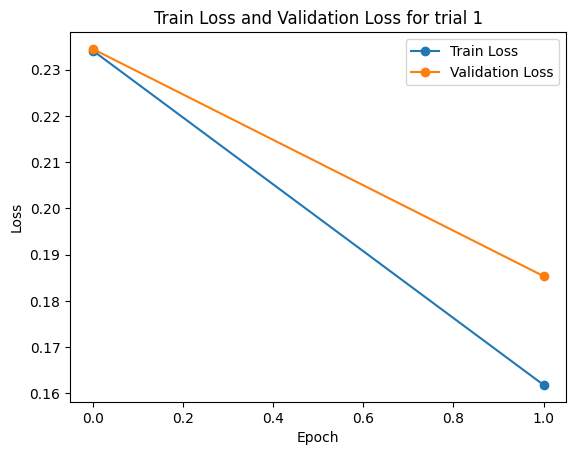

In [131]:
epochs = loss_data['epochs']
train_losses = loss_data['train_losses']
val_losses = loss_data['val_losses']


plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', marker='o')


plt.title(f'Train Loss and Validation Loss for trial {study.best_trial.number}')
plt.xlabel('Epoch')
plt.ylabel('Loss')


plt.legend()

plt.show()